In [1]:
import cv2
import numpy as np
import glob
import json
import os
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import least_squares

In [2]:
calib_path = (r"E:\Sanjay\Dodeca\realsense_color_intrinsics_1280x720.npz")

def load_camera_calibration(calib_path):
    with np.load(calib_path) as f:
        calib = dict(f)

    K = np.array(calib["camera_matrix"], dtype=np.float64)
    D = np.array(calib["dist_coeffs"], dtype=np.float64)
    return K, D
K, D = load_camera_calibration(calib_path)
print("Camera intrinsics:\n", K)
print("Distortion:", D)

Camera intrinsics:
 [[647.21075439   0.         638.43243408]
 [  0.         646.50164795 361.19393921]
 [  0.           0.           1.        ]]
Distortion: [-0.0549446   0.06270157  0.00046943  0.00102821 -0.02093403]


In [3]:
def detect_aruco_markers(image, aruco_dict_type=cv2.aruco.DICT_6X6_250):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    aruco_dict = cv2.aruco.getPredefinedDictionary(aruco_dict_type)
    params = cv2.aruco.DetectorParameters()
    detector = cv2.aruco.ArucoDetector(aruco_dict, params)

    corners, ids, _ = detector.detectMarkers(gray)

    return corners, ids
def visualize_detections(image, corners, ids):
    vis = image.copy()
    if ids is not None:
        cv2.aruco.drawDetectedMarkers(vis, corners, ids)
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title("Detected ArUco Markers")
    plt.show()

In [4]:
image_paths = glob.glob("dodeca_dataset/*.jpg")
image_paths.sort()
#image_paths = image_paths[:10]

print(f"Found {len(image_paths)} images to process")

for i, path in enumerate(image_paths, 1):
    print(f"\n[{i}/{len(image_paths)}]  {path}")
    img = cv2.imread(path)
    corners, ids = detect_aruco_markers(img)
    if ids is not None and len(ids) > 0:
        print(f"   → Detected {len(ids)} markers  IDs: {ids.flatten().tolist()}")
    else:
        print("   → No ArUco markers detected")
    #visualize_detections(img, corners, ids)

Found 72 images to process

[1/72]  dodeca_dataset\dodeca_0.jpg
   → Detected 4 markers  IDs: [5, 1, 8, 0]

[2/72]  dodeca_dataset\dodeca_1.jpg
   → Detected 4 markers  IDs: [1, 6, 7, 0]

[3/72]  dodeca_dataset\dodeca_10.jpg
   → Detected 3 markers  IDs: [5, 1, 8]

[4/72]  dodeca_dataset\dodeca_11.jpg
   → Detected 3 markers  IDs: [5, 1, 0]

[5/72]  dodeca_dataset\dodeca_12.jpg
   → Detected 3 markers  IDs: [0, 5, 1]

[6/72]  dodeca_dataset\dodeca_13.jpg
   → Detected 4 markers  IDs: [5, 0, 2, 1]

[7/72]  dodeca_dataset\dodeca_14.jpg
   → Detected 5 markers  IDs: [6, 4, 11, 7, 0]

[8/72]  dodeca_dataset\dodeca_15.jpg
   → Detected 4 markers  IDs: [4, 6, 7, 11]

[9/72]  dodeca_dataset\dodeca_16.jpg
   → Detected 3 markers  IDs: [4, 6, 7]

[10/72]  dodeca_dataset\dodeca_17.jpg
   → Detected 5 markers  IDs: [11, 3, 2, 4, 0]

[11/72]  dodeca_dataset\dodeca_18.jpg
   → Detected 3 markers  IDs: [2, 11, 0]

[12/72]  dodeca_dataset\dodeca_19.jpg
   → Detected 4 markers  IDs: [2, 0, 11, 5]

[13

In [5]:
def marker_3d_points(marker_size=20.0):
    s = marker_size / 2
    return np.array([
        [-s, -s, 0],
        [ s, -s, 0],
        [ s,  s, 0],
        [-s,  s, 0]
    ], dtype=np.float64)

In [6]:
def estimate_marker_pose(corners, K, D, marker_size=20.0):
    obj_pts = marker_3d_points(marker_size)
    img_pts = corners.reshape(-1, 2)

    success, rvec, tvec = cv2.solvePnP(
        obj_pts, img_pts, K, D,
        flags=cv2.SOLVEPNP_SQPNP
    )

    if not success:
        return None

    R_cam_marker, _ = cv2.Rodrigues(rvec)
    return R_cam_marker, tvec.reshape(3)

In [7]:
if ids is not None and len(corners) > 0:
    # Take first detected marker
    result = estimate_marker_pose(corners[0], K, D, marker_size=20.0)

    if result is not None:
        R_cam_marker, tvec = result
        print("Marker pose (cam):")
        print("R_cam_marker:\n", R_cam_marker)
        print("tvec:\n", tvec)
    else:
        print("Pose estimation failed.")

Marker pose (cam):
R_cam_marker:
 [[ 0.93197081  0.33351073  0.14213027]
 [-0.31472194  0.93888723 -0.13943056]
 [-0.17994588  0.08521369  0.97997863]]
tvec:
 [-50.4409298  -91.20796008 383.34313328]


In [8]:
def collect_marker_observations(image_paths, K, D):
    observations = []

    for img_id, path in enumerate(image_paths):
        img = cv2.imread(path)
        corners, ids = detect_aruco_markers(img)

        if ids is None:
            continue

        for i, marker_id in enumerate(ids.flatten()):
            pose = estimate_marker_pose(corners[i], K, D)
            if pose is None:
                continue

            observations.append({
                "image_id": img_id,
                "marker_id": int(marker_id),
                "corners_2d": corners[i].reshape(-1, 2),
                "R_cam_marker": pose[0],
                "t_cam_marker": pose[1]
            })

    return observations

In [9]:
observations = collect_marker_observations(image_paths, K, D)
print(f"Collected {len(observations)} marker observations")
print("First observation:", observations[4])

Collected 279 marker observations
First observation: {'image_id': 1, 'marker_id': 1, 'corners_2d': array([[696., 155.],
       [728., 164.],
       [716., 199.],
       [685., 189.]], dtype=float32), 'R_cam_marker': array([[ 0.85687708, -0.30450366,  0.41597979],
       [ 0.3725525 ,  0.92349856, -0.0914059 ],
       [-0.3563233 ,  0.23329794,  0.90476835]]), 't_cam_marker': array([  38.40115206, -104.92705701,  366.10136812])}


In [10]:
marker_ids = sorted(set(obs["marker_id"] for obs in observations))
print(marker_ids)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11]


In [11]:
def initialize_marker_object_poses(marker_ids):
    poses = {}
    for mid in marker_ids:
        poses[mid] = {
            "R": np.eye(3),
            "t": np.zeros(3)
        }
    return poses    

In [12]:
marker_obj_poses = initialize_marker_object_poses(marker_ids)
print(marker_obj_poses)

{0: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 1: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 2: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 3: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 4: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 5: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 6: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 7: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 8: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 0., 0.])}, 9: {'R': array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), 't': array([0., 

In [13]:
def initialize_object_camera_poses(observations, marker_obj_poses):
    obj_cam_poses = {}

    for obs in observations:
        img_id = obs["image_id"]
        mid = obs["marker_id"]

        if img_id in obj_cam_poses:
            continue

        R_cm = obs["R_cam_marker"]
        t_cm = obs["t_cam_marker"]

        R_om = marker_obj_poses[mid]["R"]
        t_om = marker_obj_poses[mid]["t"]

        R_co = R_cm @ R_om.T
        t_co = t_cm - R_co @ t_om

        obj_cam_poses[img_id] = {"R": R_co, "t": t_co}

    return obj_cam_poses

In [14]:
obj_cam_poses = initialize_object_camera_poses(
    observations,
    marker_obj_poses
)
print(obj_cam_poses)

{0: {'R': array([[ 0.67557775, -0.42778045,  0.60049861],
       [ 0.57508397,  0.81541961, -0.06610068],
       [-0.46138177,  0.38999327,  0.79688902]]), 't': array([  24.76882128, -105.60978062,  364.6034434 ])}, 1: {'R': array([[ 0.85687708, -0.30450366,  0.41597979],
       [ 0.3725525 ,  0.92349856, -0.0914059 ],
       [-0.3563233 ,  0.23329794,  0.90476835]]), 't': array([  38.40115206, -104.92705701,  366.10136812])}, 2: {'R': array([[ 0.87047379,  0.42745685,  0.24404102],
       [-0.34496363,  0.88346491, -0.31700134],
       [-0.35110607,  0.19175608,  0.91649012]]), 't': array([-66.65170581, -70.70339789, 379.16485018])}, 3: {'R': array([[ 9.61664899e-01,  3.84626111e-04,  2.74227049e-01],
       [ 1.71234670e-01,  7.80240963e-01, -6.01583516e-01],
       [-2.14194562e-01,  6.25478930e-01,  7.50264486e-01]]), 't': array([-13.92138155, -44.37324134, 332.50794287])}, 4: {'R': array([[-0.6804657 ,  0.70092937,  0.21369239],
       [-0.60095044, -0.70066349,  0.38461572],
    

In [15]:
print(f"Number of object poses: {len(obj_cam_poses)}")

for img_id, pose in list(obj_cam_poses.items())[:10]:
    print(f"\nImage {img_id}")
    print("R:\n", pose["R"])
    print("t:\n", pose["t"])

Number of object poses: 72

Image 0
R:
 [[ 0.67557775 -0.42778045  0.60049861]
 [ 0.57508397  0.81541961 -0.06610068]
 [-0.46138177  0.38999327  0.79688902]]
t:
 [  24.76882128 -105.60978062  364.6034434 ]

Image 1
R:
 [[ 0.85687708 -0.30450366  0.41597979]
 [ 0.3725525   0.92349856 -0.0914059 ]
 [-0.3563233   0.23329794  0.90476835]]
t:
 [  38.40115206 -104.92705701  366.10136812]

Image 2
R:
 [[ 0.87047379  0.42745685  0.24404102]
 [-0.34496363  0.88346491 -0.31700134]
 [-0.35110607  0.19175608  0.91649012]]
t:
 [-66.65170581 -70.70339789 379.16485018]

Image 3
R:
 [[ 9.61664899e-01  3.84626111e-04  2.74227049e-01]
 [ 1.71234670e-01  7.80240963e-01 -6.01583516e-01]
 [-2.14194562e-01  6.25478930e-01  7.50264486e-01]]
t:
 [-13.92138155 -44.37324134 332.50794287]

Image 4
R:
 [[-0.6804657   0.70092937  0.21369239]
 [-0.60095044 -0.70066349  0.38461572]
 [ 0.41931491  0.13329927  0.89800129]]
t:
 [ -1.63669335 -52.33974663 318.20386474]

Image 5
R:
 [[ 0.8553915  -0.43576559  0.28002453]

In [16]:
def pack_params(marker_obj_poses, obj_cam_poses, fixed_marker_id):
    params = []
    index = {}

    i = 0
    for mid, pose in marker_obj_poses.items():
        if mid == fixed_marker_id:
            continue
        rvec = R.from_matrix(pose["R"]).as_rotvec()
        params.extend(rvec)
        params.extend(pose["t"])
        index[f"marker_{mid}"] = i
        i += 6

    for img_id, pose in obj_cam_poses.items():
        rvec = R.from_matrix(pose["R"]).as_rotvec()
        params.extend(rvec)
        params.extend(pose["t"])
        index[f"image_{img_id}"] = i
        i += 6

    return np.array(params), index

In [17]:
fixed_marker_id = marker_ids[0]   # choose one marker to anchor

x0, index = pack_params(
    marker_obj_poses,
    obj_cam_poses,
    fixed_marker_id
)

print("Parameter vector size:", len(x0))
print(x0)
print(index)

Parameter vector size: 492
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+0

In [18]:
def reprojection_residuals(params, observations, K, D,
                           marker_obj_poses, obj_cam_poses,
                           index, fixed_marker_id):

    residuals = []
    obj_pts = marker_3d_points()

    for obs in observations:
        mid = obs["marker_id"]
        img_id = obs["image_id"]

        if mid == fixed_marker_id:
            R_om = marker_obj_poses[mid]["R"]
            t_om = marker_obj_poses[mid]["t"]
        else:
            idx = index[f"marker_{mid}"]
            rvec = params[idx:idx+3]
            tvec = params[idx+3:idx+6]
            R_om = R.from_rotvec(rvec).as_matrix()
            t_om = tvec

        idx = index[f"image_{img_id}"]
        rvec = params[idx:idx+3]
        tvec = params[idx+3:idx+6]
        R_co = R.from_rotvec(rvec).as_matrix()
        t_co = tvec

        pts_cam = (R_co @ (R_om @ obj_pts.T + t_om[:, None])).T + t_co
        proj, _ = cv2.projectPoints(pts_cam, np.zeros(3), np.zeros(3), K, D)

        residuals.extend((proj.reshape(-1,2) - obs["corners_2d"]).ravel())

    return np.array(residuals)

In [19]:
"""result = least_squares(
    reprojection_residuals,
    x0,
    verbose=2,
    xtol=1e-10,
    ftol=1e-10,
    args=(observations, K, D,
          marker_obj_poses, obj_cam_poses,
          index, fixed_marker_id)
)"""

'result = least_squares(\n    reprojection_residuals,\n    x0,\n    verbose=2,\n    xtol=1e-10,\n    ftol=1e-10,\n    args=(observations, K, D,\n          marker_obj_poses, obj_cam_poses,\n          index, fixed_marker_id)\n)'

In [20]:
result = least_squares(
    reprojection_residuals,
    x0,
    method='lm',
    verbose=2, 
    max_nfev=5000,
    args=(observations, K, D,
          marker_obj_poses, obj_cam_poses,
          index, fixed_marker_id)
)

`ftol` termination condition is satisfied.
Function evaluations 22, initial cost 1.2265e+06, final cost 1.9764e+02, first-order optimality 8.60e-04.


In [21]:
print("Final reprojection RMS:",
      np.sqrt(np.mean(result.fun**2)))

Final reprojection RMS: 0.4208270560000997


In [22]:
r = result.fun          # residual vector
rms = np.sqrt(np.mean(r**2))
print("RMS reprojection error:", rms)
print("Max reprojection error:", np.max(np.abs(r)))
print("Median reprojection error:", np.median(np.abs(r)))

RMS reprojection error: 0.4208270560000997
Max reprojection error: 2.821611531110875
Median reprojection error: 0.274836575799668


In [23]:
r = np.abs(result.fun)
print("Total residuals:", len(r))
print("Residuals > 10 px:", np.sum(r > 10))
print("Residuals > 20 px:", np.sum(r > 20))
print("Residuals > 50 px:", np.sum(r > 50))

Total residuals: 2232
Residuals > 10 px: 0
Residuals > 20 px: 0
Residuals > 50 px: 0


In [24]:
def unpack_optimized_params(result, marker_obj_poses, obj_cam_poses, index, fixed_marker_id):
    params = result.x

    optimized_marker_poses = {}
    optimized_obj_cam_poses = {}

    # Marker poses
    for mid in marker_obj_poses:
        if mid == fixed_marker_id:
            optimized_marker_poses[mid] = marker_obj_poses[mid]
        else:
            idx = index[f"marker_{mid}"]
            rvec = params[idx:idx+3]
            tvec = params[idx+3:idx+6]
            optimized_marker_poses[mid] = {
                "R": R.from_rotvec(rvec).as_matrix(),
                "t": tvec
            }

    # Object-camera poses
    for img_id in obj_cam_poses:
        idx = index[f"image_{img_id}"]
        rvec = params[idx:idx+3]
        tvec = params[idx+3:idx+6]
        optimized_obj_cam_poses[img_id] = {
            "R": R.from_rotvec(rvec).as_matrix(),
            "t": tvec
        }

    return optimized_marker_poses, optimized_obj_cam_poses

In [25]:
opt_marker_poses, opt_obj_cam_poses = unpack_optimized_params(
    result,
    marker_obj_poses,
    obj_cam_poses,
    index,
    fixed_marker_id
)

In [26]:
def save_marker_object_poses(marker_obj_poses, path):
    out = {}
    for mid, pose in marker_obj_poses.items():
        out[mid] = {
            "R": pose["R"].tolist(),
            "t": pose["t"].tolist()
        }

    with open(path, "w") as f:
        json.dump(out, f, indent=2)
def save_object_camera_poses(obj_cam_poses, path):
    out = {}
    for img_id, pose in obj_cam_poses.items():
        out[img_id] = {
            "R": pose["R"].tolist(),
            "t": pose["t"].tolist()
        }

    with open(path, "w") as f:
        json.dump(out, f, indent=2)
os.makedirs("output", exist_ok=True)

save_marker_object_poses(
    opt_marker_poses,
    "Rigid/optimized_marker_object_poses_SQPNP.json"
)

save_object_camera_poses(
    opt_obj_cam_poses,
    "Rigid/optimized_object_camera_poses_SQPNP.json"
)
print("Saved optimized poses to output/")

Saved optimized poses to output/


In [26]:
def visualize_reprojection(image_path, observations, 
                           opt_marker_poses, opt_obj_cam_poses,
                           K, D, output_folder):

    img = cv2.imread(image_path)
    img_vis = img.copy()

    obj_pts = marker_3d_points()

    img_id = image_paths.index(image_path)
    img_obs = [obs for obs in observations if obs["image_id"] == img_id]

    for obs in img_obs:
        mid = obs["marker_id"]

        R_om = opt_marker_poses[mid]["R"]
        t_om = opt_marker_poses[mid]["t"]

        R_co = opt_obj_cam_poses[img_id]["R"]
        t_co = opt_obj_cam_poses[img_id]["t"]

        pts_cam = (R_co @ (R_om @ obj_pts.T + t_om[:, None])).T + t_co

        proj, _ = cv2.projectPoints(
            pts_cam, np.zeros(3), np.zeros(3), K, D
        )
        proj = proj.reshape(-1, 2)

        detected = obs["corners_2d"]

        # RED = detected
        for p in detected:
            cv2.circle(img_vis, tuple(p.astype(int)), 5, (0,0,255), -1)

        # GREEN = projected
        for p in proj:
            cv2.circle(img_vis, tuple(p.astype(int)), 5, (0,255,0), -1)

    # Save image
    filename = os.path.basename(image_path)
    save_path = os.path.join(output_folder, filename)
    cv2.imwrite(save_path, img_vis)

In [27]:
output_vis_folder = "Rigid/reprojection_results_ITERATIVE"
os.makedirs(output_vis_folder, exist_ok=True)
for path in image_paths:
    visualize_reprojection(
        path,
        observations,
        opt_marker_poses,
        opt_obj_cam_poses,
        K, D,
        output_vis_folder
    )
print("Saved all reprojection visualizations.")

Saved all reprojection visualizations.


## Rcalibrating only the poses for reducing the reprojection error 

Loaded camera calibration
Loaded marker poses: 11
Processing images: 72
dodeca_dataset\dodeca_0.jpg: RMS = 0.50 px


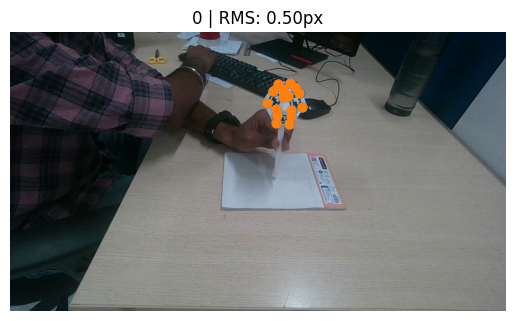

dodeca_dataset\dodeca_1.jpg: RMS = 0.74 px


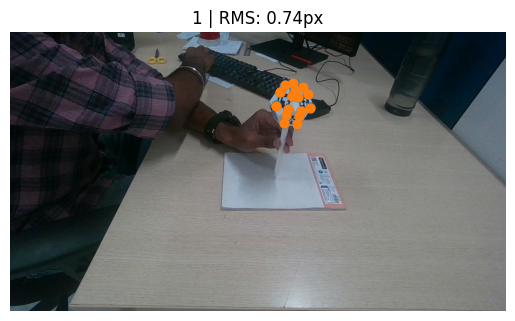

dodeca_dataset\dodeca_10.jpg: RMS = 0.50 px


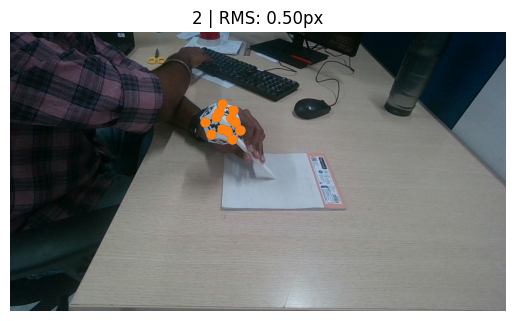

dodeca_dataset\dodeca_11.jpg: RMS = 0.49 px


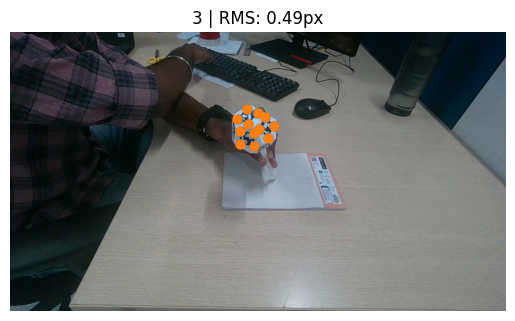

dodeca_dataset\dodeca_12.jpg: RMS = 0.46 px


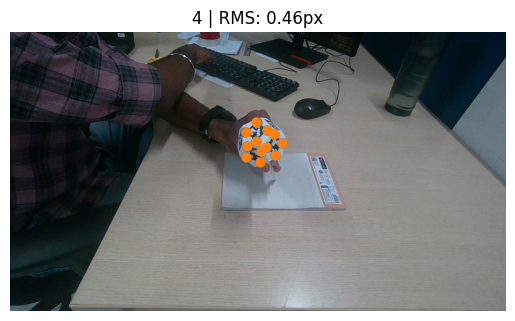

dodeca_dataset\dodeca_13.jpg: RMS = 0.59 px
dodeca_dataset\dodeca_14.jpg: RMS = 0.50 px
dodeca_dataset\dodeca_15.jpg: RMS = 0.33 px
dodeca_dataset\dodeca_16.jpg: RMS = 0.43 px
dodeca_dataset\dodeca_17.jpg: RMS = 0.55 px
dodeca_dataset\dodeca_18.jpg: RMS = 0.51 px
dodeca_dataset\dodeca_19.jpg: RMS = 0.45 px
dodeca_dataset\dodeca_2.jpg: RMS = 0.42 px
dodeca_dataset\dodeca_20.jpg: RMS = 0.61 px
dodeca_dataset\dodeca_21.jpg: RMS = 0.58 px
dodeca_dataset\dodeca_22.jpg: RMS = 0.51 px
dodeca_dataset\dodeca_23.jpg: RMS = 0.43 px
dodeca_dataset\dodeca_24.jpg: RMS = 0.42 px
dodeca_dataset\dodeca_25.jpg: RMS = 0.48 px
dodeca_dataset\dodeca_26.jpg: RMS = 0.45 px
dodeca_dataset\dodeca_27.jpg: RMS = 0.54 px
dodeca_dataset\dodeca_28.jpg: RMS = 0.56 px
dodeca_dataset\dodeca_29.jpg: RMS = 0.52 px
dodeca_dataset\dodeca_3.jpg: RMS = 0.50 px
dodeca_dataset\dodeca_30.jpg: RMS = 0.52 px
dodeca_dataset\dodeca_31.jpg: RMS = 0.29 px
dodeca_dataset\dodeca_32.jpg: RMS = 0.48 px
dodeca_dataset\dodeca_33.jpg: RMS 

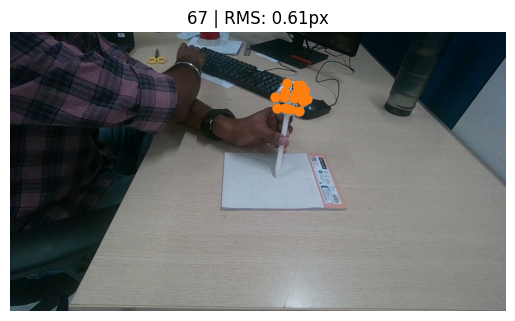

dodeca_dataset\dodeca_70.jpg: RMS = 0.45 px


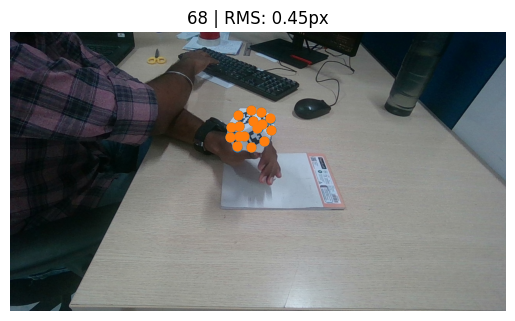

dodeca_dataset\dodeca_71.jpg: RMS = 0.46 px


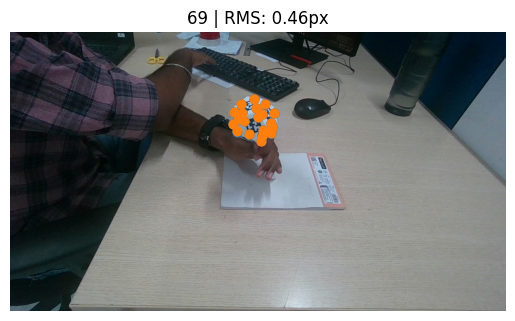

dodeca_dataset\dodeca_8.jpg: RMS = 0.51 px


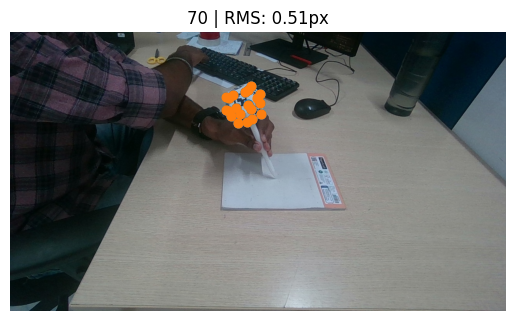

dodeca_dataset\dodeca_9.jpg: RMS = 0.49 px


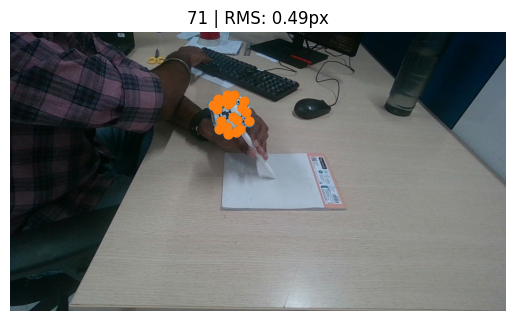

Overall RMS mean: 0.5104901241413633
Overall RMS median: 0.5066052900272379
Total valid images: 72


In [28]:
import cv2
import numpy as np
import glob
import json
import os
import matplotlib.pyplot as plt
# ==========================================
# 1. LOAD CAMERA CALIBRATION
# ==========================================
calib = np.load(r"E:\Sanjay\Dodeca\realsense_color_intrinsics_1280x720.npz")
K = calib["camera_matrix"]
D = calib["dist_coeffs"]
print("Loaded camera calibration")
# ==========================================
# 2. LOAD FROZEN MARKER POSES
# ==========================================
with open(r"E:\Sanjay\Dodeca\Rigid\optimized_marker_object_poses_SQPNP.json", "r") as f:
    marker_obj_poses_raw = json.load(f)
marker_obj_poses = {}
for k, v in marker_obj_poses_raw.items():
    marker_id = int(k)
    R = np.array(v["R"], dtype=np.float64)
    t = np.array(v["t"], dtype=np.float64).reshape(3, 1)

    marker_obj_poses[marker_id] = {
        "R": R,
        "t": t
    }
print("Loaded marker poses:", len(marker_obj_poses))
# ==========================================
# 3. SETUP ARUCO
# ==========================================
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
parameters = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, parameters)
# ==========================================
# 4. MARKER 3D CORNERS
# ==========================================
def marker_3d_points(marker_size=20.0):
    s = marker_size / 2
    return np.array([
        [-s, -s, 0],
        [ s, -s, 0],
        [ s,  s, 0],
        [-s,  s, 0]
    ], dtype=np.float64)
MARKER_SIZE = 20.0
# ==========================================
# 5. DATASET
# ==========================================
image_paths = sorted(glob.glob("dodeca_dataset/*.jpg"))
prev_rvec, prev_tvec = None, None
all_rms = []
print("Processing images:", len(image_paths))
print("=====================================")
# ==========================================
# 6. MAIN LOOP
# ==========================================
for idx, img_path in enumerate(image_paths):

    img = cv2.imread(img_path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = detector.detectMarkers(gray)

    if ids is None:
        continue

    obj_pts = []
    img_pts = []

    for i, marker_id in enumerate(ids.flatten()):

        marker_id = int(marker_id)

        if marker_id not in marker_obj_poses:
            continue

        R_o_m = marker_obj_poses[marker_id]["R"]
        t_o_m = marker_obj_poses[marker_id]["t"]

        for p_m in marker_3d_points(MARKER_SIZE):
            p_o = R_o_m @ p_m.reshape(3,1) + t_o_m
            obj_pts.append(p_o.flatten())

        img_pts.extend(corners[i][0])

    if len(obj_pts) < 6:
        continue

    obj_pts = np.array(obj_pts, dtype=np.float64)
    img_pts = np.array(img_pts, dtype=np.float64)

    # PnP
    if prev_rvec is not None:
        success, rvec, tvec = cv2.solvePnP(
            obj_pts, img_pts, K, D,
            prev_rvec, prev_tvec,
            useExtrinsicGuess=True,
            flags=cv2.SOLVEPNP_SQPNP
        )
    else:
        success, rvec, tvec = cv2.solvePnP(
            obj_pts, img_pts, K, D,
            flags=cv2.SOLVEPNP_SQPNP)

    if not success:
        continue

    prev_rvec, prev_tvec = rvec, tvec

    # ======================================
    # Reprojection Error
    # ======================================
    proj, _ = cv2.projectPoints(obj_pts, rvec, tvec, K, D)
    proj = proj.reshape(-1, 2)

    err = np.linalg.norm(img_pts - proj, axis=1)
    rms = np.mean(err)
    all_rms.append(rms)

    print(f"{img_path}: RMS = {rms:.2f} px")

    # ======================================
    # VISUALIZATION (first 5 & last 5)
    # ======================================
    proj, _ = cv2.projectPoints(obj_pts, rvec, tvec, K, D)
    proj = proj.reshape(-1, 2)

    if idx < 5 or idx >= len(image_paths) - 5:

        plt.figure()

        # Convert BGR → RGB
        rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(rgb)

        # Plot detected points (was red in cv2)
        plt.scatter(img_pts[:, 0], img_pts[:, 1], s=40)

        # Plot projected points (was green in cv2)
        plt.scatter(proj[:, 0], proj[:, 1], s=40)

        plt.title(f"{idx} | RMS: {rms:.2f}px")
        plt.axis("off")
        plt.show()

if len(all_rms) > 0:
    print("=====================================")
    print("Overall RMS mean:", np.mean(all_rms))
    print("Overall RMS median:", np.median(all_rms))
    print("Total valid images:", len(all_rms))
else:
    print("No valid PnP results.")

In [29]:
import cv2
import numpy as np
import glob
import json
import os

# ================================
# 1. LOAD CAMERA CALIBRATION
# ================================
calib = np.load(r"E:\Sanjay\Dodeca\realsense_color_intrinsics_1280x720.npz")
K = calib["camera_matrix"]
D = calib["dist_coeffs"]

# ================================
# 2. LOAD FROZEN DC MODEL
# ================================
with open(r"E:\Sanjay\Dodeca\Rigid\optimized_marker_object_poses_SQPNP.json", "r") as f:
    raw = json.load(f)

marker_obj_poses = {}
for k, v in raw.items():
    marker_id = int(k)
    R = np.array(v["R"], dtype=np.float64)
    t = np.array(v["t"], dtype=np.float64).reshape(3, 1)
    marker_obj_poses[marker_id] = (R, t)

print(f"[INFO] Loaded {len(marker_obj_poses)} frozen marker poses")

# ================================
# 3. ARUCO SETUP
# ================================
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_6X6_250)
params = cv2.aruco.DetectorParameters()
detector = cv2.aruco.ArucoDetector(aruco_dict, params)

# ================================
# 4. MARKER CORNERS (3D)
# ================================
def marker_corners_3d(size_mm=20.0):
    s = size_mm / 2
    return np.array([
        [-s, -s, 0],
        [ s, -s, 0],
        [ s,  s, 0],
        [-s,  s, 0]
    ], dtype=np.float64)

MARKER_SIZE = 20.0

# ================================
# 5. DATASET
# ================================
image_paths = sorted(glob.glob("dodeca_dataset/*.jpg"))

valid_poses = []
prev_rvec, prev_tvec = None, None

# ================================
# 6. MAIN LOOP
# ================================
for img_path in image_paths:

    img = cv2.imread(img_path)
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = detector.detectMarkers(gray)

    if ids is None:
        continue

    object_pts = []
    image_pts = []

    for i, mid in enumerate(ids.flatten()):
        if mid not in marker_obj_poses:
            continue

        R_om, t_om = marker_obj_poses[mid]

        for p_m in marker_corners_3d(MARKER_SIZE):
            p_o = R_om @ p_m.reshape(3, 1) + t_om
            object_pts.append(p_o.flatten())

        image_pts.extend(corners[i][0])

    if len(object_pts) < 8:
        continue

    object_pts = np.array(object_pts, dtype=np.float64)
    image_pts = np.array(image_pts, dtype=np.float64)

    # ================================
    # 7. SOLVE PNP
    # ================================
    if prev_rvec is not None:
        success, rvec, tvec = cv2.solvePnP(
            object_pts, image_pts, K, D,
            prev_rvec, prev_tvec,
            useExtrinsicGuess=True,
            flags=cv2.SOLVEPNP_SQPNP
        )
    else:
        success, rvec, tvec = cv2.solvePnP(
            object_pts, image_pts, K, D,
            flags=cv2.SOLVEPNP_SQPNP
        )

    if not success:
        continue

    prev_rvec, prev_tvec = rvec, tvec

    # ================================
    # 8. REPROJECTION ERROR (GATE)
    # ================================
    proj, _ = cv2.projectPoints(object_pts, rvec, tvec, K, D)
    proj = proj.reshape(-1, 2)

    errors = np.linalg.norm(image_pts - proj, axis=1)
    rms = np.mean(errors)

    # STRICT FILTER
    if rms > 3.0:
        continue

    R, _ = cv2.Rodrigues(rvec)

    valid_poses.append({
        "R": R.tolist(),
        "t": tvec.flatten().tolist(),
        "rms": float(rms)
    })

    print(f"[OK] {os.path.basename(img_path)} | RMS = {rms:.2f}px")

# ================================
# 9. SAVE FINAL POSES
# ================================
with open("valid_dodecahedron_poses_SQPNP.json", "w") as f:
    json.dump(valid_poses, f, indent=2)

print("===================================")
print(f"Saved {len(valid_poses)} valid poses")
print("Ready for pen-tip calibration")

[INFO] Loaded 11 frozen marker poses
[OK] dodeca_0.jpg | RMS = 0.50px
[OK] dodeca_1.jpg | RMS = 0.74px
[OK] dodeca_10.jpg | RMS = 0.50px
[OK] dodeca_11.jpg | RMS = 0.49px
[OK] dodeca_12.jpg | RMS = 0.46px
[OK] dodeca_13.jpg | RMS = 0.59px
[OK] dodeca_14.jpg | RMS = 0.50px
[OK] dodeca_15.jpg | RMS = 0.33px
[OK] dodeca_16.jpg | RMS = 0.43px
[OK] dodeca_17.jpg | RMS = 0.55px
[OK] dodeca_18.jpg | RMS = 0.51px
[OK] dodeca_19.jpg | RMS = 0.45px
[OK] dodeca_2.jpg | RMS = 0.42px
[OK] dodeca_20.jpg | RMS = 0.61px
[OK] dodeca_21.jpg | RMS = 0.58px
[OK] dodeca_22.jpg | RMS = 0.51px
[OK] dodeca_23.jpg | RMS = 0.43px
[OK] dodeca_24.jpg | RMS = 0.42px
[OK] dodeca_25.jpg | RMS = 0.48px
[OK] dodeca_26.jpg | RMS = 0.45px
[OK] dodeca_27.jpg | RMS = 0.54px
[OK] dodeca_28.jpg | RMS = 0.56px
[OK] dodeca_29.jpg | RMS = 0.52px
[OK] dodeca_3.jpg | RMS = 0.50px
[OK] dodeca_30.jpg | RMS = 0.52px
[OK] dodeca_31.jpg | RMS = 0.29px
[OK] dodeca_32.jpg | RMS = 0.48px
[OK] dodeca_33.jpg | RMS = 0.32px
[OK] dodeca_34.